In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegressionCV,LogisticRegression
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("data\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,0.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,0.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

In [10]:
X = df.drop('Class',axis=1)
y = df['Class']


In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size= .75,random_state=42)
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate= 0.05)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [38]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(y_proba)
threshdolds = [0.169]#np.arange(0,.9,.05)
for thresh in threshdolds:
    y_pred = (y_proba>=thresh).astype(int)
    print(f"=============================={thresh}======================")
    print("confusion_matrix\n",confusion_matrix(y_test,y_pred))
    print("accuracy_score\n",accuracy_score(y_test,y_pred))
    print("classification_report\n",classification_report(y_test,y_pred))

[9.9623852e-05 3.9072643e-06 1.0442162e-05 ... 2.4295961e-04 1.6780164e-04
 5.6551784e-05]
==============================0.169======================
confusion_matrix
 [[70810    10]
 [   22    90]]
accuracy_score
 0.9995488637004455
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70820
           1       0.90      0.80      0.85       112

    accuracy                           1.00     70932
   macro avg       0.95      0.90      0.92     70932
weighted avg       1.00      1.00      1.00     70932



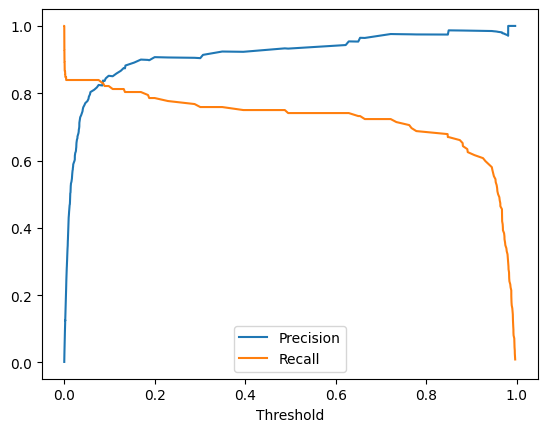

Best F1 threshold: 0.169


In [32]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

# Find threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]
print(f"Best F1 threshold: {best_thresh:.3f}")

In [40]:
from sklearn.metrics import roc_auc_score

# Binary classification
auc = roc_auc_score(y_test, y_pred)  
print(f"AUC: {auc:.4f}")

AUC: 0.9017


In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Youden's J: maximizes TPR - FPR
j_scores = tpr - fpr
best_thresh = thresholds[np.argmax(j_scores)]
print(f"Best ROC threshold: {best_thresh:.3f}")

Best ROC threshold: 0.000


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

scaler = StandardScaler()
preprocess = ColumnTransformer([("StandardScaler",scaler,X.columns)])

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.25)
X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

In [16]:
def evaluate_model(true,pred):
    report = classification_report(true,pred)
    matrix = confusion_matrix(true,pred)
    score = accuracy_score(true,pred)
    print(report)
    
    print(matrix)
    print(score)


In [17]:
models = {
    "LogisticRegression":LogisticRegression(),
    "LogisticRegressionCV":LogisticRegressionCV(),
    "AdaBoostClassifier":AdaBoostClassifier(),
    "GradientBoostingClassifier":GradientBoostingClassifier()
}
for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    print(f"--------------------------{model}---------------------")
    print(evaluate_model(y_test,pred))
        

--------------------------LogisticRegression()---------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     70820
           1       0.07      0.88      0.12       112

    accuracy                           0.98     70932
   macro avg       0.53      0.93      0.56     70932
weighted avg       1.00      0.98      0.99     70932

[[69448  1372]
 [   14    98]]
0.9804601590255456
None
--------------------------LogisticRegressionCV()---------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     70820
           1       0.07      0.88      0.14       112

    accuracy                           0.98     70932
   macro avg       0.54      0.93      0.56     70932
weighted avg       1.00      0.98      0.99     70932

[[69593  1227]
 [   14    98]]
0.982504370382902
None
--------------------------AdaBoostClassifier()---------------------
              precision    reca

KeyboardInterrupt: 